In [4]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [3]:
%pip install -r "../requirements.txt"

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


# **IHDP**


In [2]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import dowhy
from dowhy import CausalModel
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML
from engression import engression

ModuleNotFoundError: No module named 'dowhy'

In [ ]:
np.random.seed(535)
torch.manual_seed(535)

In [ ]:
data3 = pd.read_csv("https://raw.githubusercontent.com/AMLab-Amsterdam/CEVAE/master/datasets/IHDP/csv/ihdp_npci_7.csv", header = None)
col =  ["treatment", "y_factual", "y_cfactual", "mu0", "mu1" ,]
for i in range(1,26):
    col.append("x"+str(i))
data3.columns = col
data3 = data3.astype({"treatment":'bool'}, copy=False)
data3.head()

,treatment,y_factual,y_cfactual,mu0,mu1,x1,x2,x3,x4,x5,...,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25
0,True,5.715410,1.183822,1.481108,5.559723,-0.528603,-0.343455,1.128554,0.161703,-0.316603,...,1,1,1,1,0,0,0,0,0,0
1,False,2.560073,5.992945,2.172561,5.942840,-1.736945,-1.802002,0.383828,2.244320,-0.629189,...,1,1,1,1,0,0,0,0,0,0
2,False,1.018891,5.899632,0.621654,4.691561,-0.807451,-0.202946,-0.360898,-0.879606,0.808706,...,1,0,1,1,0,0,0,0,0,0
3,False,-0.191935,6.134472,0.872960,5.031068,0.390083,0.596582,-1.850350,-0.879606,-0.004017,...,1,0,1,1,0,0,0,0,0,0
4,False,3.063980,7.155660,1.476191,5.556398,-1.045229,-0.602710,0.011465,0.161703,0.683672,...,1,1,1,1,0,0,0,0,0,0


In [ ]:
covariates = [f"x{i}" for i in range(1,26)]
X = data3[covariates].to_numpy()
T = data3['treatment'].to_numpy()

ps_model = LogisticRegression(max_iter = 5000)
ps_model.fit(X,T)

ps = ps_model.predict_proba(X)[:,1]

In [ ]:
def compute_smd(X_treated, X_control):
  mean_t = X_treated.mean(axis = 0)
  mean_c = X_control.mean(axis = 0)

  var_t = X_treated.var(axis = 0, ddof = 1)
  var_c = X_control.var(axis = 0, ddof = 2)

  pooled_sd = np.sqrt((var_t + var_c)/2)
  pooled_sd = np.where(pooled_sd ==0, 1e-8, pooled_sd)

  smd = (mean_t - mean_c) / pooled_sd
  return smd

In [ ]:
X_treated = X[T ==1]
X_control = X[T ==0]

smd = compute_smd(X_treated, X_control)

smd_df = pd.DataFrame({
    "covariate": covariates,
    'SMD': smd,

    'abs(SMD)': np.abs(smd)
}).sort_values(by = 'abs(SMD)', ascending = False)

print('Mean |SMD|:', np.mean(np.abs(smd)))

Mean |SMD|: 0.18164469268119748


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
def fit_ols(X, y):
    X_const = sm.add_constant(X, has_constant="add")
    return sm.OLS(y, X_const).fit()

def predict_ols(model, X):
    X_const = sm.add_constant(X, has_constant="add")
    return np.asarray(model.predict(X_const)).reshape(-1)

def compute_pehe(tau_true, tau_hat):
    return float(np.sqrt(np.mean((tau_true - tau_hat) ** 2)))

def compute_rmse_ite(y_true, t_true, ypred1, ypred0, mu0, mu1):
    true_ite = mu1 - mu0
    pred_ite = np.zeros_like(true_ite)

    idx1 = (t_true == 1)
    idx0 = (t_true == 0)

    pred_ite[idx1] = y_true[idx1] - ypred0[idx1]
    pred_ite[idx0] = ypred1[idx0] - y_true[idx0]

    return float(np.sqrt(np.mean((true_ite - pred_ite) ** 2)))

def compute_smd(X_t, X_c):
    mean_t = X_t.mean(axis=0)
    mean_c = X_c.mean(axis=0)
    var_t = X_t.var(axis=0, ddof=1)
    var_c = X_c.var(axis=0, ddof=1)
    pooled = np.sqrt((var_t + var_c) / 2)
    pooled = np.where(pooled == 0, 1.0, pooled)
    smd = (mean_t - mean_c) / pooled
    return np.mean(np.abs(smd)), np.max(np.abs(smd)), smd

def compute_propensity_score(X, T):
    model = LogisticRegression(max_iter=5000)
    model.fit(X, T)
    ps = model.predict_proba(X)[:, 1]
    return ps, model

def ipw_ate(y, t, ps, eps=1e-3):
    y = np.asarray(y).reshape(-1)
    t = np.asarray(t).astype(int).reshape(-1)
    ps = np.asarray(ps).reshape(-1)
    ps = np.clip(ps, eps, 1 - eps)

    wt_t = t / ps
    wt_c = (1 - t) / (1 - ps)

    mu1_hat = np.sum(wt_t * y) / np.sum(wt_t)
    mu0_hat = np.sum(wt_c * y) / np.sum(wt_c)
    return float(mu1_hat - mu0_hat)

def estimate_causal_forest(X_train, T_train, Y_train, X_test, random_state=123):
    est = CausalForestDML(
        model_y=RandomForestRegressor(
            n_estimators=200,
            min_samples_leaf=5,
            random_state=random_state
        ),
        model_t=LogisticRegression(max_iter=3000),
        n_estimators=500,
        min_samples_leaf=5,
        discrete_treatment=True,
        random_state=random_state
    )
    est.fit(Y_train, T_train, X=X_train)
    tau_hat = est.effect(X_test)
    tau_hat = np.asarray(tau_hat).reshape(-1)
    ate_hat = float(np.mean(tau_hat))
    return tau_hat, ate_hat

def fit_engression_model(X, y, num_epochs=300, lr=0.01, batch_size=128, verbose=False):
    x_t = torch.tensor(np.asarray(X), dtype=torch.float32, device=device)
    y_t = torch.tensor(np.asarray(y).reshape(-1, 1), dtype=torch.float32, device=device)

    model = engression(
        x_t,
        y_t,
        lr=lr,
        num_epochs=num_epochs,
        batch_size=min(batch_size, len(X)),
        device=device,
        verbose=verbose
    )
    return model

def engression_sample(model, X, sample_size=1):
    x_t = torch.tensor(np.asarray(X), dtype=torch.float32, device=device)
    y_samp = model.sample(x_t, sample_size=sample_size, expand_dim=True)

    if hasattr(y_samp, "detach"):
        y_samp = y_samp.detach().cpu().numpy()

    y_samp = np.asarray(y_samp)

    if y_samp.ndim == 3:
        y_samp = y_samp[:, 0, :]
    elif y_samp.ndim == 2 and y_samp.shape[1] == 1:
        y_samp = y_samp[:, 0][:, None]

    return y_samp


# =========================================================
# 2. Main pipeline
# =========================================================
def baseline_to_augmentation(
    df,
    test_size=75,
    random_state=42,
    eng_epochs=300,
    eng_lr=0.01,
    verbose=False
):
    # -----------------------------------------------------
    # raw data
    # -----------------------------------------------------
    X = df[covariates].to_numpy()
    T = df["treatment"].astype(int).to_numpy()
    Y = df["y_factual"].to_numpy()

    mu0_all = df["mu0"].to_numpy()
    mu1_all = df["mu1"].to_numpy()
    tau_true_all = mu1_all - mu0_all

    # -----------------------------------------------------
    # train / test split
    # -----------------------------------------------------
    idx = np.arange(len(df))
    train_idx, test_idx = train_test_split(
        idx,
        test_size=test_size,
        random_state=random_state,
        stratify=T
    )

    X_train_raw, X_test_raw = X[train_idx], X[test_idx]
    T_train, T_test = T[train_idx], T[test_idx]
    Y_train, Y_test = Y[train_idx], Y[test_idx]

    mu0_test = mu0_all[test_idx]
    mu1_test = mu1_all[test_idx]
    tau_true_test = tau_true_all[test_idx]
    ate_true = float(np.mean(tau_true_test))

    # -----------------------------------------------------
    # scale X
    # -----------------------------------------------------
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)

    # treated / control split
    Xt = X_train[T_train == 1]
    Xc = X_train[T_train == 0]
    Yt = Y_train[T_train == 1]
    Yc = Y_train[T_train == 0]

    mean_abs_smd_before, max_abs_smd_before, smd_before = compute_smd(Xt, Xc)

    # =====================================================
    # 1. baseline models
    # =====================================================

    # ---------- OLS T-learner ----------
    model_c_base = fit_ols(Xc, Yc)
    model_t_base = fit_ols(Xt, Yt)

    ypred0_ols_base = predict_ols(model_c_base, X_test)
    ypred1_ols_base = predict_ols(model_t_base, X_test)

    tau_hat_ols_base = ypred1_ols_base - ypred0_ols_base
    pehe_ols_base = compute_pehe(tau_true_test, tau_hat_ols_base)
    rmse_ite_ols_base = compute_rmse_ite(
        y_true=Y_test,
        t_true=T_test,
        ypred1=ypred1_ols_base,
        ypred0=ypred0_ols_base,
        mu0=mu0_test,
        mu1=mu1_test
    )
    ate_hat_ols_base = float(np.mean(tau_hat_ols_base))
    ate_err_ols_base = abs(ate_true - ate_hat_ols_base)

    # ---------- Causal Forest ----------
    tau_hat_cf_base, ate_hat_cf_base = estimate_causal_forest(
        X_train, T_train, Y_train, X_test, random_state=random_state
    )
    pehe_cf_base = compute_pehe(tau_true_test, tau_hat_cf_base)

    ypred1_cf_base = Y_test + (1 - T_test) * tau_hat_cf_base
    ypred0_cf_base = Y_test - T_test * tau_hat_cf_base
    rmse_ite_cf_base = compute_rmse_ite(
        y_true=Y_test,
        t_true=T_test,
        ypred1=ypred1_cf_base,
        ypred0=ypred0_cf_base,
        mu0=mu0_test,
        mu1=mu1_test
    )
    ate_err_cf_base = abs(ate_true - ate_hat_cf_base)

    # ---------- IPW ----------
    ps_train, ps_model = compute_propensity_score(X_train, T_train)
    ps_test = ps_model.predict_proba(X_test)[:, 1]
    ate_hat_ipw_base = ipw_ate(Y_test, T_test, ps_test)
    ate_err_ipw_base = abs(ate_true - ate_hat_ipw_base)

    baseline_metrics = {
        "pehe_ols_base": pehe_ols_base,
        "rmse_ite_ols_base": rmse_ite_ols_base,
        "ate_err_ols_base": ate_err_ols_base,
        "pehe_cf_base": pehe_cf_base,
        "rmse_ite_cf_base": rmse_ite_cf_base,
        "ate_err_cf_base": ate_err_cf_base,
        "ate_err_ipw_base": ate_err_ipw_base,
    }

    # =====================================================
    # 2. train joint model P(Y|X,T)
    # =====================================================
    XT_train_joint = np.column_stack([X_train, T_train])

    engr_joint = fit_engression_model(
        XT_train_joint,
        Y_train,
        num_epochs=eng_epochs,
        lr=eng_lr,
        verbose=verbose
    )

    # =====================================================
    # 3. weak overlap region
    # threshold: T = 0 & ps in [0.08, 0.25]
    # =====================================================
    weak_idx = np.where((T_train == 0) & (ps_train >= 0.08) & (ps_train <= 0.25))[0]

    X_weak = X_train[weak_idx]
    ps_weak = ps_train[weak_idx]

    # =====================================================
    # 4. synthetic treated covariate
    # weak-overlap control
    # =====================================================
    X_syn = X_weak.copy()

    # =====================================================
    # 5. synthetic treated outcome
    # Sampling Y_syn | (X_syn, T=1) from engression
    # =====================================================
    XT_syn_input = np.column_stack([
        X_syn,
        np.ones(len(X_syn), dtype=float)
    ])

    Y_syn = engression_sample(
        engr_joint,
        XT_syn_input,
        sample_size=1
    ).reshape(-1)

    # =====================================================
    # 6. augmented dataset
    # =====================================================
    X_train_aug = np.vstack([X_train, X_syn])
    T_train_aug = np.concatenate([T_train, np.ones(len(X_syn), dtype=int)])
    Y_train_aug = np.concatenate([Y_train, Y_syn])

    Xt_aug = X_train_aug[T_train_aug == 1]
    Xc_aug = X_train_aug[T_train_aug == 0]
    mean_abs_smd_after, max_abs_smd_after, smd_after = compute_smd(Xt_aug, Xc_aug)

    augmentation_info = {
        "weak_idx": weak_idx,
        "n_weak": len(weak_idx),
        "X_syn": X_syn,
        "Y_syn": Y_syn,
        "X_train_aug": X_train_aug,
        "T_train_aug": T_train_aug,
        "Y_train_aug": Y_train_aug,
        "mean_abs_smd_before": mean_abs_smd_before,
        "mean_abs_smd_after": mean_abs_smd_after,
        "max_abs_smd_before": max_abs_smd_before,
        "max_abs_smd_after": max_abs_smd_after,
        "ps_train": ps_train,
        "ps_test": ps_test,
        "ps_weak": ps_weak,
        "scaler": scaler,
        "X_train": X_train,
        "T_train": T_train,
        "Y_train": Y_train,
        "X_test": X_test,
        "T_test": T_test,
        "Y_test": Y_test,
        "mu0_test": mu0_test,
        "mu1_test": mu1_test,
        "tau_true_test": tau_true_test,
        "ate_true": ate_true,
    }

    return baseline_metrics, augmentation_info

In [ ]:
# =========================================================
# 7. Estimate using augmented data
# 8. baseline vs augmented
# =========================================================

def evaluate_augmented_models(baseline_metrics, augmentation_info, random_state=123):
    # unpack
    X_train_aug = augmentation_info["X_train_aug"]
    T_train_aug = augmentation_info["T_train_aug"]
    Y_train_aug = augmentation_info["Y_train_aug"]

    X_test = augmentation_info["X_test"]
    T_test = augmentation_info["T_test"]
    Y_test = augmentation_info["Y_test"]

    mu0_test = augmentation_info["mu0_test"]
    mu1_test = augmentation_info["mu1_test"]
    tau_true_test = augmentation_info["tau_true_test"]
    ate_true = augmentation_info["ate_true"]

    # -----------------------------------------------------
    # 7-1. OLS T-learner on augmented data
    # -----------------------------------------------------
    Xc_aug = X_train_aug[T_train_aug == 0]
    Yc_aug = Y_train_aug[T_train_aug == 0]
    Xt_aug = X_train_aug[T_train_aug == 1]
    Yt_aug = Y_train_aug[T_train_aug == 1]

    model_c_aug = fit_ols(Xc_aug, Yc_aug)
    model_t_aug = fit_ols(Xt_aug, Yt_aug)

    ypred0_ols_aug = predict_ols(model_c_aug, X_test)
    ypred1_ols_aug = predict_ols(model_t_aug, X_test)

    tau_hat_ols_aug = ypred1_ols_aug - ypred0_ols_aug
    pehe_ols_aug = compute_pehe(tau_true_test, tau_hat_ols_aug)
    rmse_ite_ols_aug = compute_rmse_ite(
        y_true=Y_test,
        t_true=T_test,
        ypred1=ypred1_ols_aug,
        ypred0=ypred0_ols_aug,
        mu0=mu0_test,
        mu1=mu1_test
    )
    ate_hat_ols_aug = float(np.mean(tau_hat_ols_aug))
    ate_err_ols_aug = abs(ate_true - ate_hat_ols_aug)

    # -----------------------------------------------------
    # 7-2. Causal Forest on augmented data
    # -----------------------------------------------------
    tau_hat_cf_aug, ate_hat_cf_aug = estimate_causal_forest(
        X_train_aug, T_train_aug, Y_train_aug, X_test, random_state=random_state
    )
    pehe_cf_aug = compute_pehe(tau_true_test, tau_hat_cf_aug)

    ypred1_cf_aug = Y_test + (1 - T_test) * tau_hat_cf_aug
    ypred0_cf_aug = Y_test - T_test * tau_hat_cf_aug
    rmse_ite_cf_aug = compute_rmse_ite(
        y_true=Y_test,
        t_true=T_test,
        ypred1=ypred1_cf_aug,
        ypred0=ypred0_cf_aug,
        mu0=mu0_test,
        mu1=mu1_test
    )
    ate_err_cf_aug = abs(ate_true - ate_hat_cf_aug)

    # -----------------------------------------------------
    # 7-3. IPW on augmented data
    # -----------------------------------------------------
    ps_model_aug = LogisticRegression(max_iter=5000)
    ps_model_aug.fit(X_train_aug, T_train_aug)
    ps_test_aug = ps_model_aug.predict_proba(X_test)[:, 1]

    ate_hat_ipw_aug = ipw_ate(Y_test, T_test, ps_test_aug)
    ate_err_ipw_aug = abs(ate_true - ate_hat_ipw_aug)

    # -----------------------------------------------------
    # 8. baseline vs augmented
    # -----------------------------------------------------
    comparison = {
        # baseline
        "pehe_ols_base": baseline_metrics["pehe_ols_base"],
        "rmse_ite_ols_base": baseline_metrics["rmse_ite_ols_base"],
        "ate_err_ols_base": baseline_metrics["ate_err_ols_base"],

        "pehe_cf_base": baseline_metrics["pehe_cf_base"],
        "rmse_ite_cf_base": baseline_metrics["rmse_ite_cf_base"],
        "ate_err_cf_base": baseline_metrics["ate_err_cf_base"],

        "ate_err_ipw_base": baseline_metrics["ate_err_ipw_base"],

        # augmented
        "pehe_ols_aug": pehe_ols_aug,
        "rmse_ite_ols_aug": rmse_ite_ols_aug,
        "ate_err_ols_aug": ate_err_ols_aug,

        "pehe_cf_aug": pehe_cf_aug,
        "rmse_ite_cf_aug": rmse_ite_cf_aug,
        "ate_err_cf_aug": ate_err_cf_aug,

        "ate_err_ipw_aug": ate_err_ipw_aug,

        # gains
        "pehe_gain_ols": baseline_metrics["pehe_ols_base"] - pehe_ols_aug,
        "rmse_ite_gain_ols": baseline_metrics["rmse_ite_ols_base"] - rmse_ite_ols_aug,
        "ate_gain_ols": baseline_metrics["ate_err_ols_base"] - ate_err_ols_aug,

        "pehe_gain_cf": baseline_metrics["pehe_cf_base"] - pehe_cf_aug,
        "rmse_ite_gain_cf": baseline_metrics["rmse_ite_cf_base"] - rmse_ite_cf_aug,
        "ate_gain_cf": baseline_metrics["ate_err_cf_base"] - ate_err_cf_aug,

        "ate_gain_ipw": baseline_metrics["ate_err_ipw_base"] - ate_err_ipw_aug,

        # overlap / augmentation info
        "n_weak": augmentation_info["n_weak"],
        "n_synthetic_added": len(augmentation_info["X_syn"]),
        "mean_abs_smd_before": augmentation_info["mean_abs_smd_before"],
        "mean_abs_smd_after": augmentation_info["mean_abs_smd_after"],
        "syn_outcome_rmse": augmentation_info.get("syn_outcome_rmse", np.nan),
    }

    return comparison

-------

In [ ]:
all_results = []

for seed in range(100, 200):  # 100

    baseline_metrics, augmentation_info = baseline_to_augmentation(
        data3,
        test_size=75,
        random_state=seed,
        eng_epochs=300,
        eng_lr=0.01,
        verbose=False
    )

    comparison = evaluate_augmented_models(
        baseline_metrics,
        augmentation_info,
        random_state=seed
    )

    comparison["seed"] = seed
    all_results.append(comparison)

# DataFrame
results_df = pd.DataFrame(all_results)

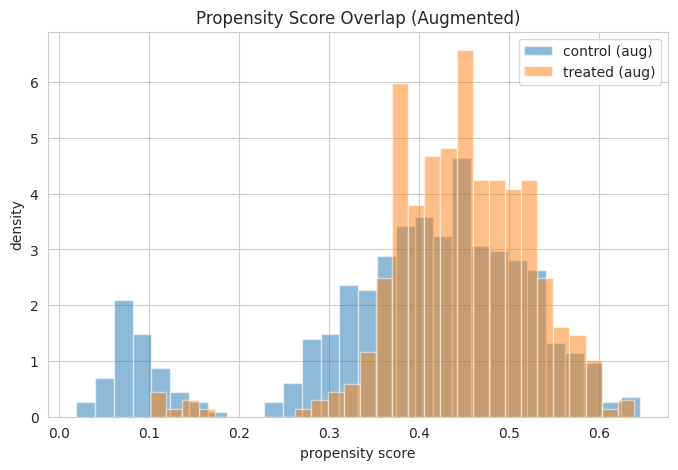

In [ ]:
# baseline propensity score
ps_base, _ = compute_propensity_score(
    augmentation_info["X_train"],
    augmentation_info["T_train"]
)

# augmented propensity score
ps_aug, _ = compute_propensity_score(
    augmentation_info["X_train_aug"],
    augmentation_info["T_train_aug"]
)

T_base = augmentation_info["T_train"]
T_aug = augmentation_info["T_train_aug"]

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(ps_aug[T_aug == 0], bins=30, alpha=0.5, density=True, label="control (aug)")
plt.hist(ps_aug[T_aug == 1], bins=30, alpha=0.5, density=True, label="treated (aug)")

plt.xlabel("propensity score")
plt.ylabel("density")
plt.title("Propensity Score Overlap (Augmented)")
plt.legend()
plt.show()

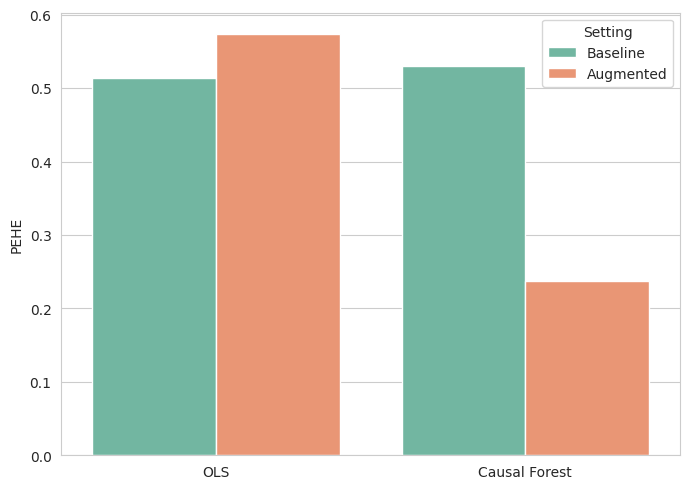

In [ ]:
sns.set_style("whitegrid")

df_plot = pd.DataFrame({
    "Model": ["OLS","Causal Forest"],
    "Baseline":[
        comparison["pehe_ols_base"],
        comparison["pehe_cf_base"]
    ],
    "Augmented":[
        comparison["pehe_ols_aug"],
        comparison["pehe_cf_aug"]
    ]
})

df_plot = df_plot.melt(id_vars="Model",
                       var_name="Setting",
                       value_name="PEHE")

plt.figure(figsize=(7,5))

sns.barplot(
    data=df_plot,
    x="Model",
    y="PEHE",
    hue="Setting",
    palette="Set2"
)

plt.ylabel("PEHE")
plt.xlabel("")
plt.tight_layout()

plt.show()

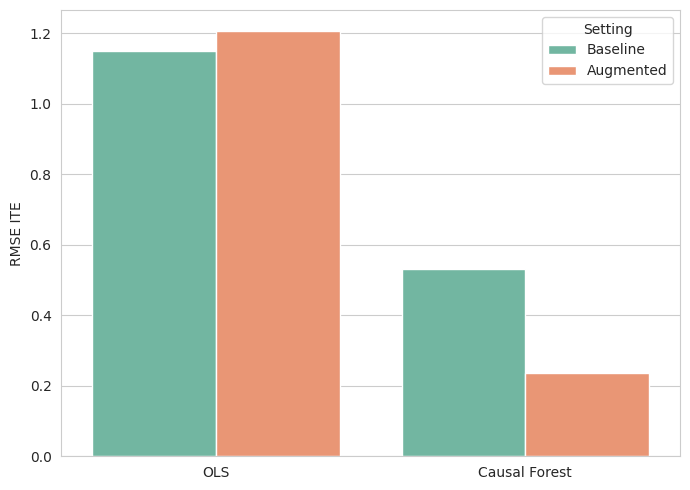

In [ ]:
df_plot = pd.DataFrame({
    "Model":["OLS","Causal Forest"],
    "Baseline":[
        comparison["rmse_ite_ols_base"],
        comparison["rmse_ite_cf_base"]
    ],
    "Augmented":[
        comparison["rmse_ite_ols_aug"],
        comparison["rmse_ite_cf_aug"]
    ]
})

df_plot = df_plot.melt(id_vars="Model",
                       var_name="Setting",
                       value_name="RMSE_ITE")

plt.figure(figsize=(7,5))

sns.barplot(
    data=df_plot,
    x="Model",
    y="RMSE_ITE",
    hue="Setting",
    palette="Set2"
)

plt.ylabel("RMSE ITE")
plt.xlabel("")
plt.tight_layout()

plt.show()

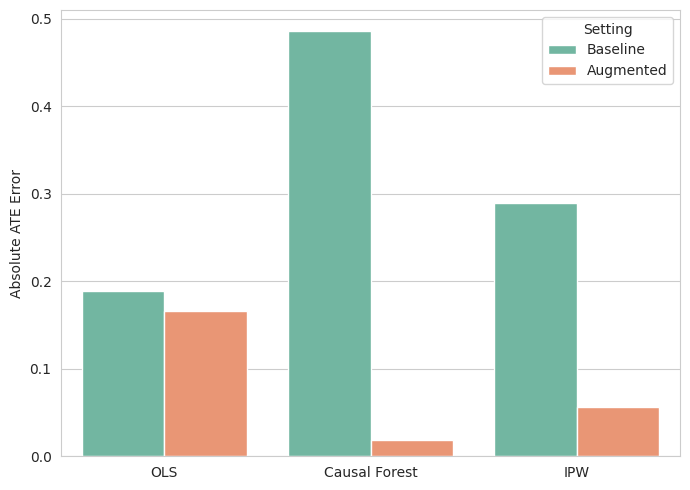

In [ ]:
df_plot = pd.DataFrame({
    "Model":["OLS","Causal Forest","IPW"],
    "Baseline":[
        comparison["ate_err_ols_base"],
        comparison["ate_err_cf_base"],
        comparison["ate_err_ipw_base"]
    ],
    "Augmented":[
        comparison["ate_err_ols_aug"],
        comparison["ate_err_cf_aug"],
        comparison["ate_err_ipw_aug"]
    ]
})

df_plot = df_plot.melt(id_vars="Model",
                       var_name="Setting",
                       value_name="ATE_error")

plt.figure(figsize=(7,5))

sns.barplot(
    data=df_plot,
    x="Model",
    y="ATE_error",
    hue="Setting",
    palette="Set2"
)

plt.ylabel("Absolute ATE Error")
plt.xlabel("")
plt.tight_layout()

plt.show()

# **Lalonde**


- X: 8 covariates
- T : treat
- Y : 1978 earnings after training

In [ ]:
df = pd.read_csv('lalonde.csv')

In [ ]:
df['treat'].value_counts()

,count
treat,
0,429
1,185


In [ ]:
covariates = ['age', 'educ', 'black', 'hispan', 'married', 'nodegree', 're74', 're75']
X = df[covariates].to_numpy()
T = df['treat'].to_numpy()

ps_model = LogisticRegression(max_iter = 5000)
ps_model.fit(X,T)

ps = ps_model.predict_proba(X)[:,1]

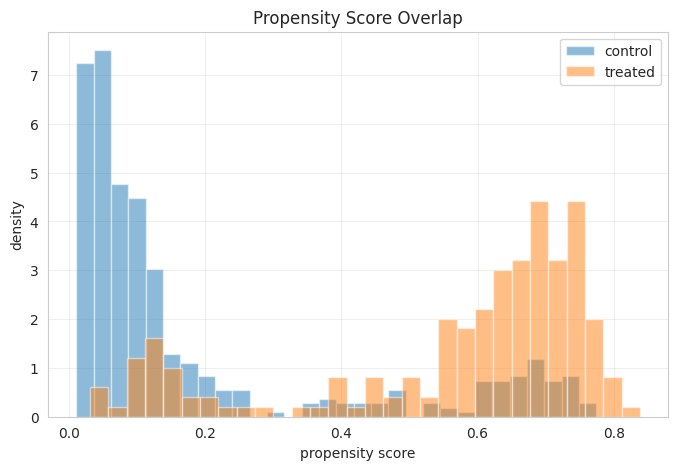

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(ps[T==0], bins=30, alpha=0.5, density=True, label="control")
plt.hist(ps[T==1], bins=30, alpha=0.5, density=True, label="treated")

plt.xlabel("propensity score")
plt.ylabel("density")
plt.legend()

plt.grid(True, alpha = 0.3)
plt.show()

In [ ]:
# =========================================================
# 1. Helper functions
# =========================================================
def fit_ols(X, y):
    X_const = sm.add_constant(X, has_constant="add")
    return sm.OLS(y, X_const).fit()

def predict_ols(model, X):
    X_const = sm.add_constant(X, has_constant="add")
    return np.asarray(model.predict(X_const)).reshape(-1)

def compute_smd(X_t, X_c):
    mean_t = X_t.mean(axis=0)
    mean_c = X_c.mean(axis=0)
    var_t = X_t.var(axis=0, ddof=1)
    var_c = X_c.var(axis=0, ddof=1)
    pooled = np.sqrt((var_t + var_c) / 2)
    pooled = np.where(pooled == 0, 1.0, pooled)
    smd = (mean_t - mean_c) / pooled
    return np.mean(np.abs(smd)), np.max(np.abs(smd)), smd

def compute_propensity_score(X, T):
    model = LogisticRegression(max_iter=5000)
    model.fit(X, T)
    ps = model.predict_proba(X)[:, 1]
    return ps, model

def ipw_att(y, t, ps, eps=1e-3):
    """
    Hajek-style ATT estimator:
    ATT = E[Y | T=1] - weighted E[Y(0) | T=1]
    """
    y = np.asarray(y).reshape(-1)
    t = np.asarray(t).astype(int).reshape(-1)
    ps = np.asarray(ps).reshape(-1)
    ps = np.clip(ps, eps, 1 - eps)

    y1 = y[t == 1]
    y0 = y[t == 0]
    ps0 = ps[t == 0]

    mu1_hat = np.mean(y1)

    w0 = ps0 / (1 - ps0)
    mu0_hat = np.sum(w0 * y0) / np.sum(w0)

    return float(mu1_hat - mu0_hat)

def estimate_causal_forest(X_train, T_train, Y_train, X_test, random_state=123):
    est = CausalForestDML(
        model_y=RandomForestRegressor(
            n_estimators=200,
            min_samples_leaf=5,
            random_state=random_state
        ),
        model_t=LogisticRegression(max_iter=3000),
        n_estimators=500,
        min_samples_leaf=5,
        discrete_treatment=True,
        random_state=random_state
    )
    est.fit(Y_train, T_train, X=X_train)
    tau_hat = est.effect(X_test)
    tau_hat = np.asarray(tau_hat).reshape(-1)
    return tau_hat

def fit_engression_model(X, y, num_epochs=300, lr=0.01, batch_size=128, verbose=False):
    x_t = torch.tensor(np.asarray(X), dtype=torch.float32, device=device)
    y_t = torch.tensor(np.asarray(y).reshape(-1, 1), dtype=torch.float32, device=device)

    model = engression(
        x_t,
        y_t,
        lr=lr,
        num_epochs=num_epochs,
        batch_size=min(batch_size, len(X)),
        device=device,
        verbose=verbose
    )
    return model

def engression_sample(model, X, sample_size=1):
    x_t = torch.tensor(np.asarray(X), dtype=torch.float32, device=device)
    y_samp = model.sample(x_t, sample_size=sample_size, expand_dim=True)

    if hasattr(y_samp, "detach"):
        y_samp = y_samp.detach().cpu().numpy()

    y_samp = np.asarray(y_samp)

    if y_samp.ndim == 3:
        y_samp = y_samp[:, 0, :]
    elif y_samp.ndim == 2 and y_samp.shape[1] == 1:
        y_samp = y_samp[:, 0][:, None]

    return y_samp

# =========================================================
# 2. Main pipeline
# =========================================================
def baseline_to_augmentation_jobs(
    df,
    test_size=0.2,
    random_state=42,
    eng_epochs=300,
    eng_lr=0.01,
    verbose=False
):
    # -----------------------------------------------------
    # raw data
    # -----------------------------------------------------
    X = df[covariates].to_numpy()
    T = df["treat"].astype(int).to_numpy()
    Y = df["re78"].to_numpy()

    # -----------------------------------------------------
    # train / test split
    # -----------------------------------------------------
    idx = np.arange(len(df))
    train_idx, test_idx = train_test_split(
        idx,
        test_size=test_size,
        random_state=random_state,
        stratify=T
    )

    X_train_raw, X_test_raw = X[train_idx], X[test_idx]
    T_train, T_test = T[train_idx], T[test_idx]
    Y_train, Y_test = Y[train_idx], Y[test_idx]

    # -----------------------------------------------------
    # scale X
    # -----------------------------------------------------
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)

    Xt = X_train[T_train == 1]
    Xc = X_train[T_train == 0]
    Yt = Y_train[T_train == 1]
    Yc = Y_train[T_train == 0]

    mean_abs_smd_before, max_abs_smd_before, smd_before = compute_smd(Xt, Xc)

    # =====================================================
    # 1. baseline models
    # =====================================================

    # ---------- OLS  ----------
    model_c_base = fit_ols(Xc, Yc)
    model_t_base = fit_ols(Xt, Yt)

    ypred0_ols_base = predict_ols(model_c_base, X_test)
    ypred1_ols_base = predict_ols(model_t_base, X_test)

    tau_hat_ols_base = ypred1_ols_base - ypred0_ols_base

    if np.sum(T_test == 1) > 0:
        att_hat_ols_base = float(np.mean(tau_hat_ols_base[T_test == 1]))
    else:
        att_hat_ols_base = np.nan

    # ---------- Causal Forest ----------
    tau_hat_cf_base = estimate_causal_forest(
        X_train, T_train, Y_train, X_test, random_state=random_state
    )

    if np.sum(T_test == 1) > 0:
        att_hat_cf_base = float(np.mean(tau_hat_cf_base[T_test == 1]))
    else:
        att_hat_cf_base = np.nan

    # ---------- IPW ATT ----------
    ps_train, ps_model = compute_propensity_score(X_train, T_train)
    ps_test = ps_model.predict_proba(X_test)[:, 1]
    att_hat_ipw_base = ipw_att(Y_test, T_test, ps_test)

    baseline_metrics = {
        "att_hat_ols_base": att_hat_ols_base,
        "att_hat_cf_base": att_hat_cf_base,
        "att_hat_ipw_base": att_hat_ipw_base,
    }

    # =====================================================
    # 2. train joint model P(Y|X,T)
    # =====================================================
    XT_train_joint = np.column_stack([X_train, T_train])

    engr_joint = fit_engression_model(
        XT_train_joint,
        Y_train,
        num_epochs=eng_epochs,
        lr=eng_lr,
        verbose=verbose
    )

    # =====================================================
    # 3. weak overlap region
    # T=0 & ps in [0.1, 0.3]
    # =====================================================
    weak_idx = np.where((T_train == 0) & (ps_train >= 0.00) & (ps_train <= 0.3))[0]

    X_weak = X_train[weak_idx]
    ps_weak = ps_train[weak_idx]

    # =====================================================
    # 4. synthetic treated covariate
    # =====================================================
    X_syn = X_weak.copy()

    # =====================================================
    # 5. synthetic treated outcome
    # =====================================================
    XT_syn_input = np.column_stack([
        X_syn,
        np.ones(len(X_syn), dtype=float)
    ])

    Y_syn = engression_sample(
        engr_joint,
        XT_syn_input,
        sample_size=1
    ).reshape(-1)

    # =====================================================
    # 6. augmented dataset
    # =====================================================
    X_train_aug = np.vstack([X_train, X_syn])
    T_train_aug = np.concatenate([T_train, np.ones(len(X_syn), dtype=int)])
    Y_train_aug = np.concatenate([Y_train, Y_syn])

    Xt_aug = X_train_aug[T_train_aug == 1]
    Xc_aug = X_train_aug[T_train_aug == 0]
    mean_abs_smd_after, max_abs_smd_after, smd_after = compute_smd(Xt_aug, Xc_aug)

    augmentation_info = {
        "weak_idx": weak_idx,
        "n_weak": len(weak_idx),
        "X_syn": X_syn,
        "Y_syn": Y_syn,
        "X_train_aug": X_train_aug,
        "T_train_aug": T_train_aug,
        "Y_train_aug": Y_train_aug,
        "mean_abs_smd_before": mean_abs_smd_before,
        "mean_abs_smd_after": mean_abs_smd_after,
        "max_abs_smd_before": max_abs_smd_before,
        "max_abs_smd_after": max_abs_smd_after,
        "ps_train": ps_train,
        "ps_test": ps_test,
        "ps_weak": ps_weak,
        "scaler": scaler,
        "X_train": X_train,
        "T_train": T_train,
        "Y_train": Y_train,
        "X_test": X_test,
        "T_test": T_test,
        "Y_test": Y_test,
    }

    return baseline_metrics, augmentation_info



def evaluate_augmented_models_jobs(baseline_metrics, augmentation_info, random_state=123):
    X_train_aug = augmentation_info["X_train_aug"]
    T_train_aug = augmentation_info["T_train_aug"]
    Y_train_aug = augmentation_info["Y_train_aug"]

    X_test = augmentation_info["X_test"]
    T_test = augmentation_info["T_test"]
    Y_test = augmentation_info["Y_test"]

    # ---------- OLS ----------
    Xc_aug = X_train_aug[T_train_aug == 0]
    Yc_aug = Y_train_aug[T_train_aug == 0]
    Xt_aug = X_train_aug[T_train_aug == 1]
    Yt_aug = Y_train_aug[T_train_aug == 1]

    model_c_aug = fit_ols(Xc_aug, Yc_aug)
    model_t_aug = fit_ols(Xt_aug, Yt_aug)

    ypred0_ols_aug = predict_ols(model_c_aug, X_test)
    ypred1_ols_aug = predict_ols(model_t_aug, X_test)

    tau_hat_ols_aug = ypred1_ols_aug - ypred0_ols_aug
    att_hat_ols_aug = float(np.mean(tau_hat_ols_aug[T_test == 1])) if np.sum(T_test == 1) > 0 else np.nan

    # ---------- Causal Forest ----------
    tau_hat_cf_aug = estimate_causal_forest(
        X_train_aug, T_train_aug, Y_train_aug, X_test, random_state=random_state
    )
    att_hat_cf_aug = float(np.mean(tau_hat_cf_aug[T_test == 1])) if np.sum(T_test == 1) > 0 else np.nan

    # ---------- IPW ATT ----------
    ps_model_aug = LogisticRegression(max_iter=5000)
    ps_model_aug.fit(X_train_aug, T_train_aug)
    ps_test_aug = ps_model_aug.predict_proba(X_test)[:, 1]
    att_hat_ipw_aug = ipw_att(Y_test, T_test, ps_test_aug)

    comparison = {
        "att_hat_ols_base": baseline_metrics["att_hat_ols_base"],
        "att_hat_ols_aug": att_hat_ols_aug,

        "att_hat_cf_base": baseline_metrics["att_hat_cf_base"],
        "att_hat_cf_aug": att_hat_cf_aug,

        "att_hat_ipw_base": baseline_metrics["att_hat_ipw_base"],
        "att_hat_ipw_aug": att_hat_ipw_aug,

        "att_gain_ols": baseline_metrics["att_hat_ols_base"] - att_hat_ols_aug,
        "att_gain_cf": baseline_metrics["att_hat_cf_base"] - att_hat_cf_aug,
        "att_gain_ipw": baseline_metrics["att_hat_ipw_base"] - att_hat_ipw_aug,

        "n_weak": augmentation_info["n_weak"],
        "n_synthetic_added": len(augmentation_info["X_syn"]),
        "mean_abs_smd_before": augmentation_info["mean_abs_smd_before"],
        "mean_abs_smd_after": augmentation_info["mean_abs_smd_after"],
    }

    return comparison

## result

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

results = []

for seed in range(100, 110):
    baseline_metrics, augmentation_info = baseline_to_augmentation_jobs(
        df,
        test_size=0.2,
        random_state=seed,
        eng_epochs=300,
        eng_lr=0.01,
        verbose=False
    )

    comparison = evaluate_augmented_models_jobs(
        baseline_metrics,
        augmentation_info,
        random_state=seed
    )

    results.append(comparison)

results_df = pd.DataFrame(results)

mean_results = results_df.mean()

result_table = pd.DataFrame({
    "Metric": [
        "ATT Hat (OLS)",
        "ATT Hat (Causal Forest)",
        "ATT Hat (IPW)"
    ],
    "Baseline": [
        mean_results["att_hat_ols_base"],
        mean_results["att_hat_cf_base"],
        mean_results["att_hat_ipw_base"]
    ],
    "Augmented": [
        mean_results["att_hat_ols_aug"],
        mean_results["att_hat_cf_aug"],
        mean_results["att_hat_ipw_aug"]
    ]
})

result_table["Difference"] = result_table["Augmented"] - result_table["Baseline"]


balance_table = pd.DataFrame({
    "Metric": [
        "Weak region samples",
        "Synthetic samples added",
        "Mean |SMD| before",
        "Mean |SMD| after"
    ],
    "Value": [
        mean_results["n_weak"],
        mean_results["n_synthetic_added"],
        mean_results["mean_abs_smd_before"],
        mean_results["mean_abs_smd_after"]
    ]
})

print("===== Mean Result Table =====")
print(result_table.round(3))

print("\n===== Mean Balance Table =====")
print(balance_table.round(3))

===== Mean Result Table =====
                    Metric  Baseline  Augmented  Difference
0            ATT Hat (OLS)  1634.746   1599.749     -34.997
1  ATT Hat (Causal Forest)  1285.211   1781.897     496.686
2            ATT Hat (IPW)   757.488   -275.620   -1033.108

===== Mean Balance Table =====
                    Metric    Value
0      Weak region samples  273.300
1  Synthetic samples added  273.300
2        Mean |SMD| before    0.512
3         Mean |SMD| after    0.089


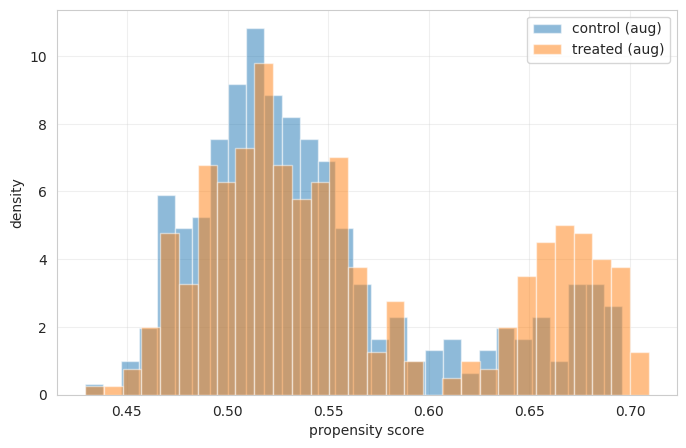

In [ ]:
# baseline propensity score
ps_base, _ = compute_propensity_score(
    augmentation_info["X_train"],
    augmentation_info["T_train"]
)

# augmented propensity score
ps_aug, _ = compute_propensity_score(
    augmentation_info["X_train_aug"],
    augmentation_info["T_train_aug"]
)

T_base = augmentation_info["T_train"]
T_aug = augmentation_info["T_train_aug"]

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(ps_aug[T_aug == 0], bins=30, alpha=0.5, density=True, label="control (aug)")
plt.hist(ps_aug[T_aug == 1], bins=30, alpha=0.5, density=True, label="treated (aug)")

plt.xlabel("propensity score")
plt.ylabel("density")
plt.legend()

plt.grid(True, alpha = 0.3)
plt.show()